# Lambda=4: EffSU2/TwoLocal - Final Results

Notebook created by HLD for the work arXiv: 2503.13368 [quant-ph, hep-th]

In this notebook, we process all results for the SU(2) bosonic matrix model at $\Lambda=4$ using EfficientSU2 and TwoLocal ansatzes.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
def get_last_val(df):
    val_list = []
    name_list = []
    for i in range(len(df.columns)):
        lv = df[df.columns[i]].dropna().to_numpy()[-1]
        val_list.append(np.round(lv,5))
        name_list.append(df.columns[i])
    return name_list, val_list

def plot_e(df, ax, Ee):
    ax.axhline(Ee, color = 'red', linestyle='dashed', label = 'Exact energy')
    for i in range(len(df.columns)):
        ax.plot(np.arange(len(df[df.columns[i]])),df[df.columns[i]],
                color = color_list[i], 
                 label=df.columns[i])
    ax.set_xlabel('Iterations', fontsize = 13)
    ax.set_ylabel('Energy', fontsize = 15)
    ax.legend()

def create_df_last_val(df_cs, df_ct, df_ss, df_st, ll):
    ns1, vs1 = get_last_val(df_cs)
    nt1, vt1 = get_last_val(df_ct)

    ns2, vs2 = get_last_val(df_ss)
    nt2, vt2 = get_last_val(df_st)
    l_cn = np.concatenate((ns1, nt1), axis = 0)
    l_cv = np.concatenate((vs1, vt1), axis = 0)
    l_sn = np.concatenate((ns2, nt2), axis = 0)
    l_sv = np.concatenate((vs2, vt2), axis = 0)

    df = pd.DataFrame({'name': l_cn, 'cobyla_values': l_cv, 'spsa_values': l_sv})
    df.set_index('name', inplace = True)
    df_name =f'results/l{ll}_last_val.csv'
    df.to_csv(df_name)
    print(f'file saved as {df_name}')
    return df

In [5]:
su2_ansatz = ['effsu2_Ry_c', 'effsu2_Rz_c', 'effsu2_RyRz_c', 'effsu2_RyY_c',
             'effsu2_Ry_f', 'effsu2_Rz_f', 'effsu2_RyRz_f', 'effsu2_RyY_f']
tl_ansatz = ['tl_Ry_c', 'tl_Rz_c', 'tl_RyRz_c', 'tl_RyY_c',
             'tl_Ry_f', 'tl_Rz_f', 'tl_RyRz_f', 'tl_RyY_f']

# lambda = 0.2

In [7]:
E_02 = 3.13406
df_02_cs= pd.read_csv('results/qve_l4_l=0.2_effsu2_cobyla.csv')
df_02_ct= pd.read_csv('results/qve_l4_l=0.2_twolocal_cobyla.csv')
df_02_ss= pd.read_csv('results/qve_l4_l=0.2_effsu2_spsa.csv')
df_02_st= pd.read_csv('results/qve_l4_l=0.2_twolocal_spsa.csv')

In [9]:
df_02_cs.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_02_cs.columns = su2_ansatz

df_02_ct.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_02_ct.columns = tl_ansatz

df_02_ss.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_02_ss.columns = su2_ansatz

df_02_st.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_02_st.columns = tl_ansatz

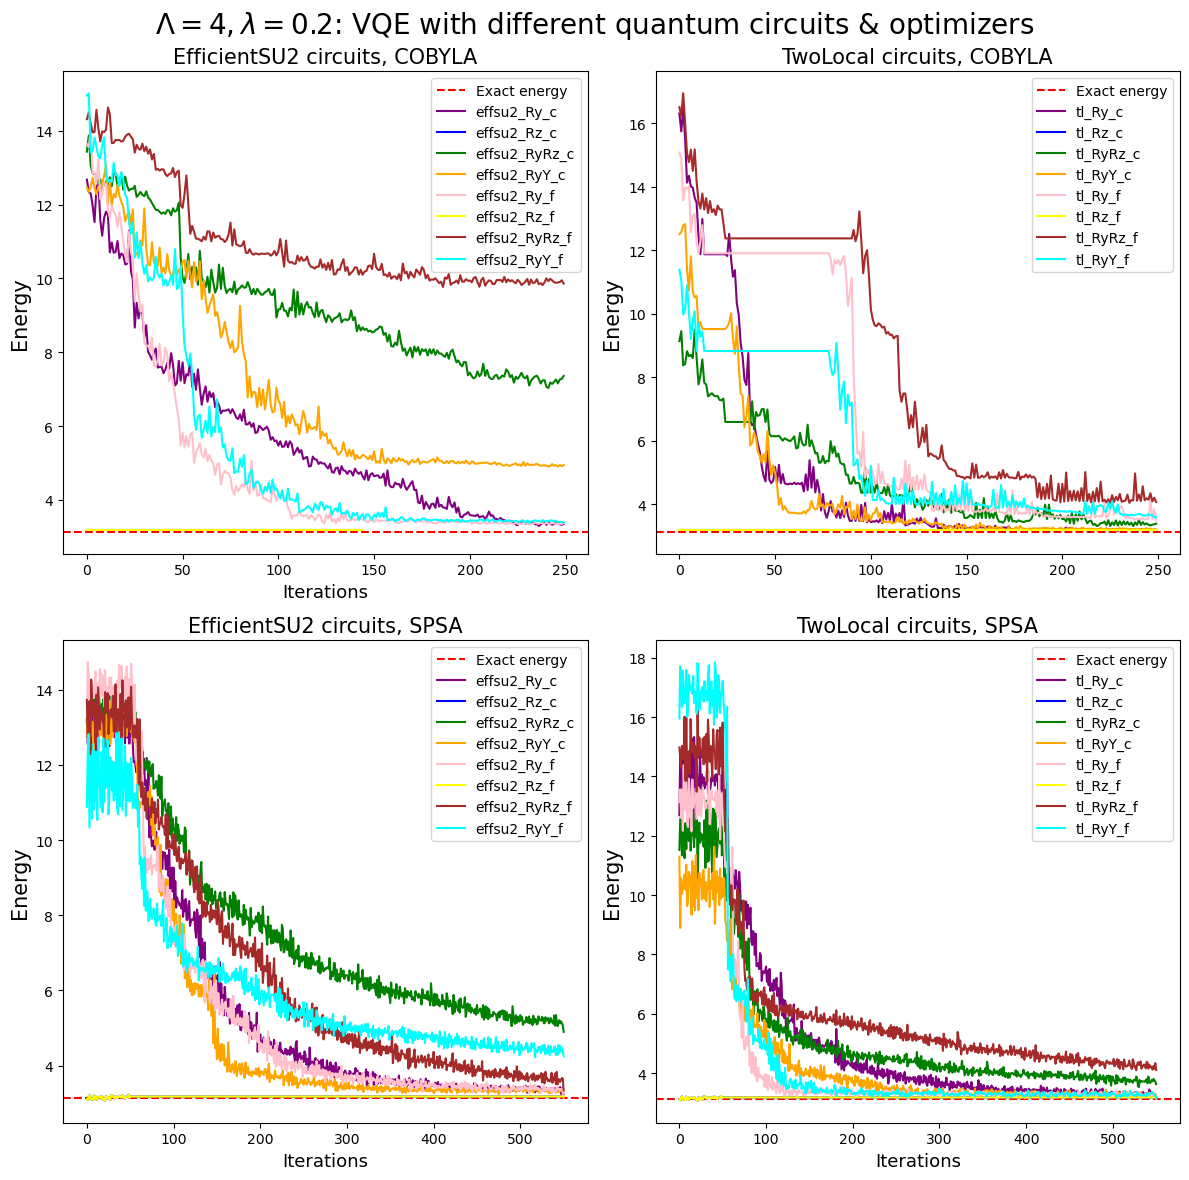

In [11]:
fig, ax = plt.subplots(2,2, figsize=(12,12), tight_layout = True)
color_list = ['purple', 'blue', 'green', 'orange', 'pink', 'yellow', 'brown', 'cyan']

plot_e(df_02_cs, ax[0,0], E_02)
ax[0,0].set_title('EfficientSU2 circuits, COBYLA', fontsize = 15)

plot_e(df_02_ct, ax[0,1], E_02)
ax[0,1].set_title('TwoLocal circuits, COBYLA', fontsize = 15)

plot_e(df_02_ss, ax[1,0], E_02)
ax[1,0].set_title('EfficientSU2 circuits, SPSA', fontsize = 15)

plot_e(df_02_st, ax[1,1], E_02)
ax[1,1].set_title('TwoLocal circuits, SPSA', fontsize = 15)

plt.suptitle('$\Lambda=4, \lambda=0.2$: VQE with different quantum circuits & optimizers', fontsize = 20)
plt.savefig('L=4_l=02_convergence_curves.png')

In [13]:
df_l02 = create_df_last_val(df_02_cs, df_02_ct, df_02_ss, df_02_st, 0.2)
df_l02

file saved as results/l0.2_last_val.csv


,cobyla_values,spsa_values
name,,
effsu2_Ry_c,3.34450,3.23204
effsu2_Rz_c,3.17910,3.17910
effsu2_RyRz_c,7.35898,4.89771
effsu2_RyY_c,4.93931,3.14605
effsu2_Ry_f,3.37026,3.19555
effsu2_Rz_f,3.17910,3.17910
effsu2_RyRz_f,9.85983,3.33804
effsu2_RyY_f,3.38528,4.24528
tl_Ry_c,3.18228,3.18339


In [15]:
df_l02 - E_02

,cobyla_values,spsa_values
name,,
effsu2_Ry_c,0.21044,0.09798
effsu2_Rz_c,0.04504,0.04504
effsu2_RyRz_c,4.22492,1.76365
effsu2_RyY_c,1.80525,0.01199
effsu2_Ry_f,0.23620,0.06149
effsu2_Rz_f,0.04504,0.04504
effsu2_RyRz_f,6.72577,0.20398
effsu2_RyY_f,0.25122,1.11122
tl_Ry_c,0.04822,0.04933


# lambda = 0.5

In [17]:
E_05 =3.29894
df_05_cs= pd.read_csv('results/qve_l4_l=0.5_effsu2_cobyla.csv')
df_05_ct= pd.read_csv('results/qve_l4_l=0.5_twolocal_cobyla.csv')
df_05_ss= pd.read_csv('results/qve_l4_l=0.5_effsu2_spsa.csv')
df_05_st= pd.read_csv('results/qve_l4_l=0.5_twolocal_spsa.csv')

In [19]:
df_05_cs.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_05_cs.columns = su2_ansatz

df_05_ct.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_05_ct.columns = tl_ansatz

df_05_ss.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_05_ss.columns = su2_ansatz

df_05_st.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_05_st.columns = tl_ansatz

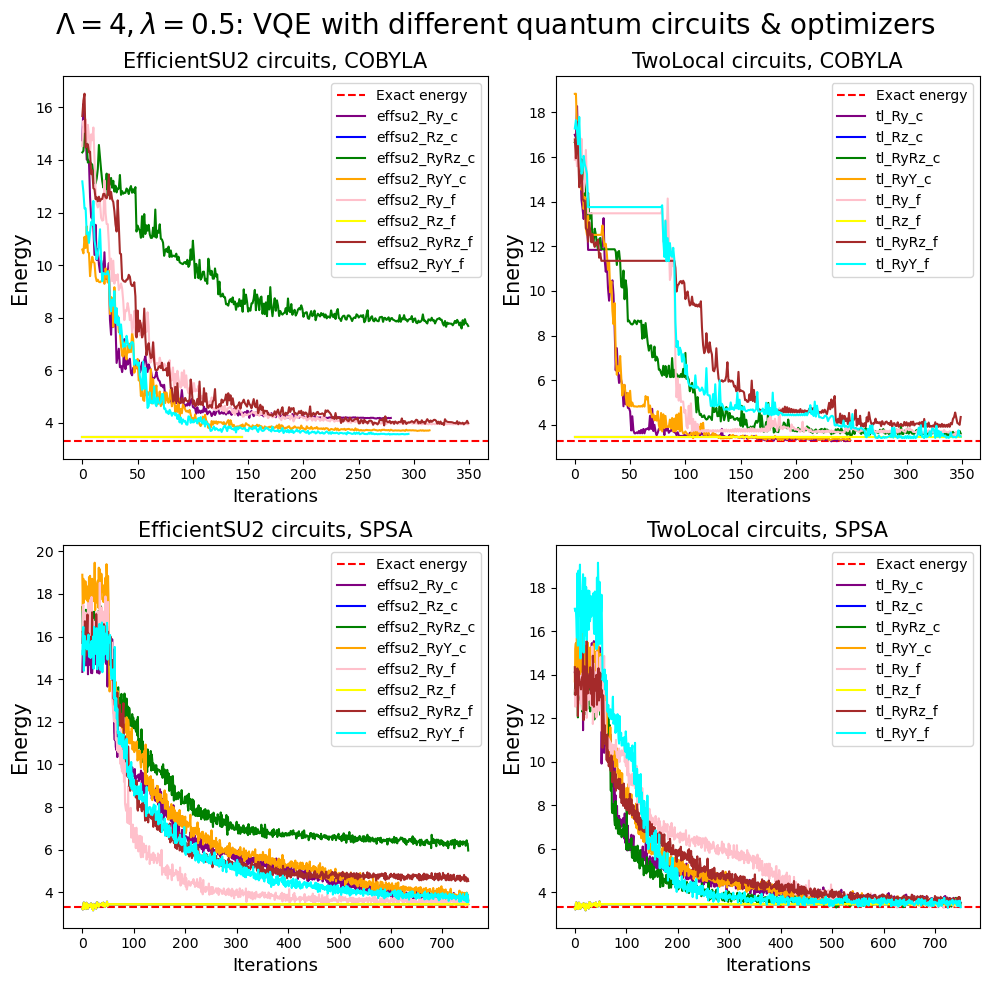

In [21]:
fig, ax = plt.subplots(2,2, figsize=(10,10), tight_layout = True)
color_list = ['purple', 'blue', 'green', 'orange', 'pink', 'yellow', 'brown', 'cyan']

plot_e(df_05_cs, ax[0,0], E_05)
ax[0,0].set_title('EfficientSU2 circuits, COBYLA', fontsize = 15)

plot_e(df_05_ct, ax[0,1], E_05)
ax[0,1].set_title('TwoLocal circuits, COBYLA', fontsize = 15)

plot_e(df_05_ss, ax[1,0], E_05)
ax[1,0].set_title('EfficientSU2 circuits, SPSA', fontsize = 15)

plot_e(df_05_st, ax[1,1], E_05)
ax[1,1].set_title('TwoLocal circuits, SPSA', fontsize = 15)

plt.suptitle('$\Lambda=4, \lambda=0.5$: VQE with different quantum circuits & optimizers', fontsize = 20)
plt.savefig('L=4_l=05_convergence_curves.png')

In [23]:
df_l05 = create_df_last_val(df_05_cs, df_05_ct, df_05_ss, df_05_st, 0.5)
df_l05

file saved as results/l0.5_last_val.csv


,cobyla_values,spsa_values
name,,
effsu2_Ry_c,4.18830,3.61873
effsu2_Rz_c,3.44775,3.44775
effsu2_RyRz_c,7.68608,5.96494
effsu2_RyY_c,3.71764,3.66239
effsu2_Ry_f,3.95226,3.40536
effsu2_Rz_f,3.44775,3.44775
effsu2_RyRz_f,3.99438,4.53325
effsu2_RyY_f,3.58207,3.55380
tl_Ry_c,3.30724,3.49978


In [25]:
df_l05 - E_05

,cobyla_values,spsa_values
name,,
effsu2_Ry_c,0.88936,0.31979
effsu2_Rz_c,0.14881,0.14881
effsu2_RyRz_c,4.38714,2.66600
effsu2_RyY_c,0.41870,0.36345
effsu2_Ry_f,0.65332,0.10642
effsu2_Rz_f,0.14881,0.14881
effsu2_RyRz_f,0.69544,1.23431
effsu2_RyY_f,0.28313,0.25486
tl_Ry_c,0.00830,0.20084


# lambda = 1.0

In [57]:
E_10 = 3.52625
df_10_cs= pd.read_csv('results/qve_l4_l=1.0_effsu2_cobyla.csv')
df_10_ct= pd.read_csv('results/qve_l4_l=1.0_twolocal_cobyla.csv')
df_10_ss= pd.read_csv('results/qve_l4_l=1.0_effsu2_spsa.csv')
df_10_st= pd.read_csv('results/qve_l4_l=1.0_twolocal_spsa.csv')

In [59]:
df_10_cs.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_10_cs.columns = su2_ansatz

df_10_ct.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_10_ct.columns = tl_ansatz

df_10_ss.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_10_ss.columns = su2_ansatz

df_10_st.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_10_st.columns = tl_ansatz

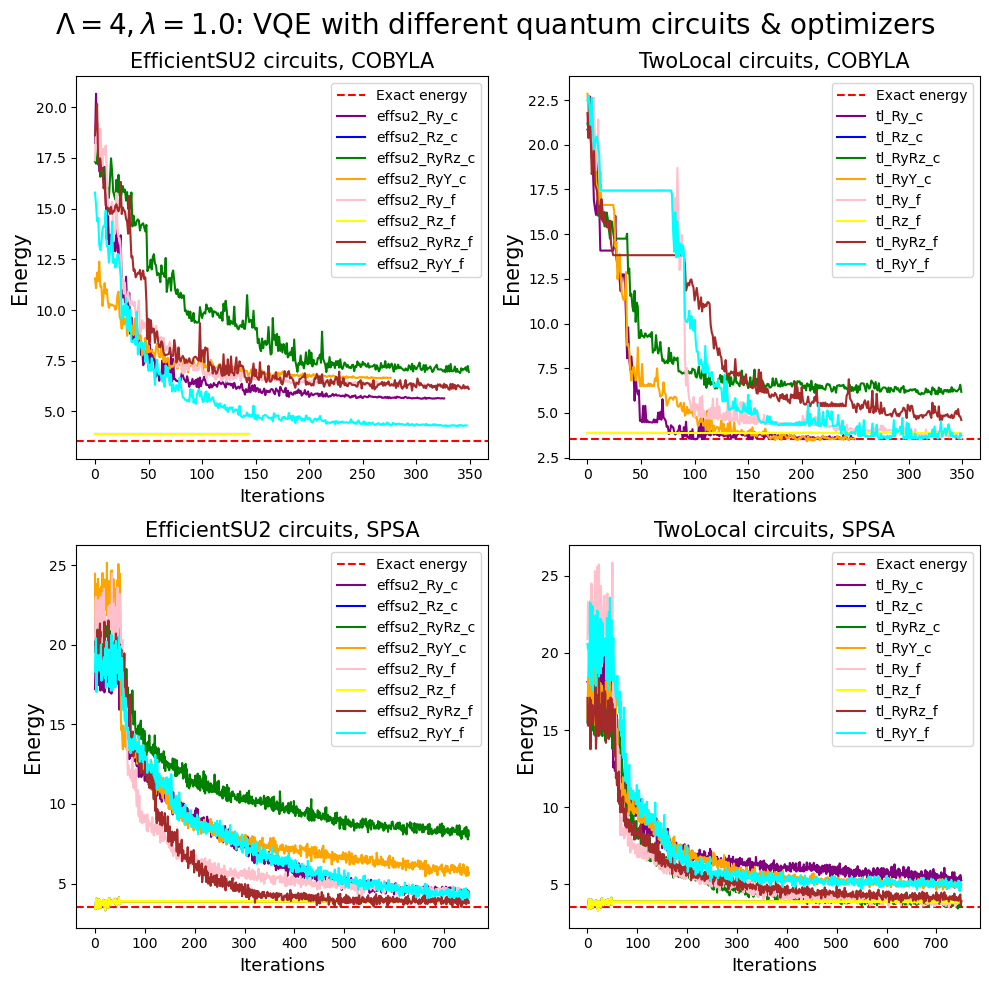

In [61]:
fig, ax = plt.subplots(2,2, figsize=(10,10), tight_layout = True)
color_list = ['purple', 'blue', 'green', 'orange', 'pink', 'yellow', 'brown', 'cyan']

plot_e(df_10_cs, ax[0,0], E_10)
ax[0,0].set_title('EfficientSU2 circuits, COBYLA', fontsize = 15)

plot_e(df_10_ct, ax[0,1], E_10)
ax[0,1].set_title('TwoLocal circuits, COBYLA', fontsize = 15)

plot_e(df_10_ss, ax[1,0], E_10)
ax[1,0].set_title('EfficientSU2 circuits, SPSA', fontsize = 15)

plot_e(df_10_st, ax[1,1], E_10)
ax[1,1].set_title('TwoLocal circuits, SPSA', fontsize = 15)
plt.suptitle('$\Lambda=4, \lambda=1.0$: VQE with different quantum circuits & optimizers', fontsize = 20)
plt.savefig('L=4_l=10_convergence_curves.png')

In [63]:
df_l10 = create_df_last_val(df_10_cs, df_10_ct, df_10_ss, df_10_st, 1.0)
df_l10

file saved as results/l1.0_last_val.csv


,cobyla_values,spsa_values
name,,
effsu2_Ry_c,5.64314,4.22957
effsu2_Rz_c,3.89550,3.89550
effsu2_RyRz_c,6.94346,8.01018
effsu2_RyY_c,6.65659,5.67670
effsu2_Ry_f,6.30709,4.19845
effsu2_Rz_f,3.89550,3.89550
effsu2_RyRz_f,6.11065,3.78857
effsu2_RyY_f,4.30899,4.10703
tl_Ry_c,3.53869,5.26669


In [65]:
df_l10 - E_10

,cobyla_values,spsa_values
name,,
effsu2_Ry_c,2.11689,0.70332
effsu2_Rz_c,0.36925,0.36925
effsu2_RyRz_c,3.41721,4.48393
effsu2_RyY_c,3.13034,2.15045
effsu2_Ry_f,2.78084,0.67220
effsu2_Rz_f,0.36925,0.36925
effsu2_RyRz_f,2.58440,0.26232
effsu2_RyY_f,0.78274,0.58078
tl_Ry_c,0.01244,1.74044


# lambda =2.0

In [39]:
E_20 = 3.89548

df_20_cs= pd.read_csv('results/qve_l4_l=2.0_effsu2_cobyla.csv')
df_20_ct= pd.read_csv('results/qve_l4_l=2.0_twolocal_cobyla.csv')
df_20_ss= pd.read_csv('results/qve_l4_l=2.0_effsu2_spsa.csv')
df_20_st= pd.read_csv('results/qve_l4_l=2.0_twolocal_spsa.csv')

In [41]:
df_20_cs.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_cs.columns = su2_ansatz

df_20_ct.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_ct.columns = tl_ansatz

df_20_ss.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_ss.columns = su2_ansatz

df_20_st.drop(['Unnamed: 0'], axis = 1, inplace=True)
df_20_st.columns = tl_ansatz

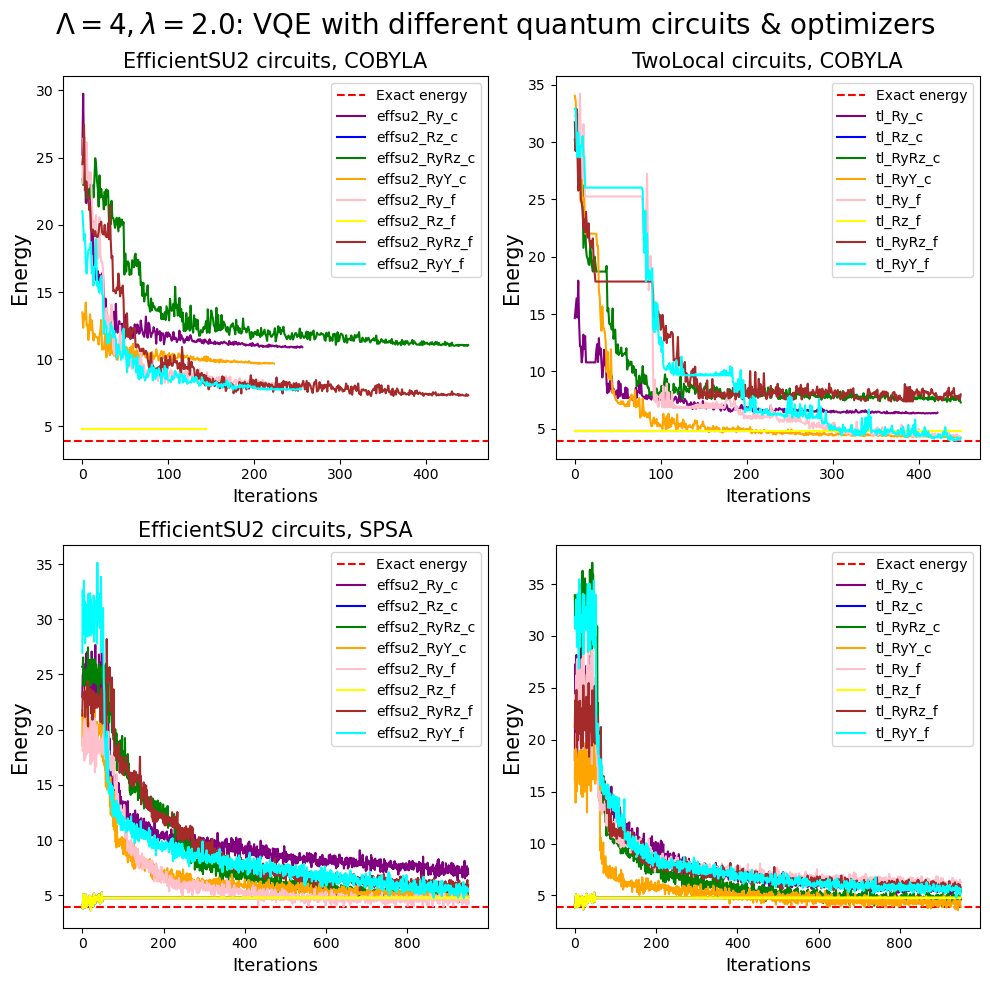

In [43]:
fig, ax = plt.subplots(2,2, figsize=(10,10), tight_layout = True)
color_list = ['purple', 'blue', 'green', 'orange', 'pink', 'yellow', 'brown', 'cyan']

plot_e(df_20_cs, ax[0,0], E_20)
ax[0,0].set_title('EfficientSU2 circuits, COBYLA', fontsize = 15)

plot_e(df_20_ct, ax[0,1], E_20)
ax[0,1].set_title('TwoLocal circuits, COBYLA', fontsize = 15)

plot_e(df_20_ss, ax[1,0], E_20)
ax[1,0].set_title('EfficientSU2 circuits, SPSA', fontsize = 15)

plot_e(df_20_st, ax[1,1], E_20)

plt.suptitle('$\Lambda=4, \lambda=2.0$: VQE with different quantum circuits & optimizers', fontsize = 20)
plt.savefig('L=4_l=20_convergence_curves.png')

In [44]:
df_l20 = create_df_last_val(df_20_cs, df_20_ct, df_20_ss, df_20_st, 2.0)
df_l20

file saved as results/l2.0_last_val.csv


,cobyla_values,spsa_values
name,,
effsu2_Ry_c,10.89956,6.92786
effsu2_Rz_c,4.79100,4.79100
effsu2_RyRz_c,11.05988,4.32874
effsu2_RyY_c,9.68253,4.94393
effsu2_Ry_f,8.01434,4.20670
effsu2_Rz_f,4.79100,4.79100
effsu2_RyRz_f,7.32845,5.87643
effsu2_RyY_f,7.79339,5.54155
tl_Ry_c,6.39657,5.45181


# Find best ansatz

In [47]:
E_02 = 3.13406
E_05 = 3.29894
E_10 = 3.52625
E_20 = 3.89548

In [67]:
df_l02 = pd.read_csv('results/l0.2_last_val.csv')
df_l05 = pd.read_csv('results/l0.5_last_val.csv')
df_l10 = pd.read_csv('results/l1.0_last_val.csv')
df_l20 = pd.read_csv('results/l2.0_last_val.csv')

df_l02.set_index('name', inplace = True)
df_l05.set_index('name', inplace = True)
df_l10.set_index('name', inplace = True)
df_l20.set_index('name', inplace = True)

In [51]:
def find_best_ansatz(df, Ee):
    c_i = np.argmin(np.abs(df['cobyla_values']- Ee))
    print(f'Exact energy is {Ee}')
    print(f'Best ansatz for COBYLA is {df.index[c_i]} with value: {df.cobyla_values[c_i]}')
    s_i = np.argmin(np.abs(df['spsa_values']- Ee))
    print(f'Best ansatz for SPSA is {df.index[s_i]} with value: {df.spsa_values[s_i]}')
    diff_c = np.abs(df.cobyla_values[c_i]-Ee)
    diff_s = np.abs(df.spsa_values[s_i]-Ee)
    if diff_c < diff_s:
        print(f'Best ansatz overall is {df.index[c_i]}')
    if diff_c > diff_s:
         print(f'Best ansatz overall is {df.index[s_i]}')

In [51]:
find_best_ansatz(df_l02, E_02)

Exact energy is 3.13406
Best ansatz for COBYLA is effsu2_Rz_c with value: 3.1791
Best ansatz for SPSA is tl_RyY_c with value: 3.13679
Best ansatz overall is tl_RyY_c


In [53]:
find_best_ansatz(df_l05, E_05)

Exact energy is 3.29894
Best ansatz for COBYLA is tl_Ry_c with value: 3.30724
Best ansatz for SPSA is tl_RyY_f with value: 3.30641
Best ansatz overall is tl_RyY_f


In [69]:
find_best_ansatz(df_l10, E_10)

Exact energy is 3.52625
Best ansatz for COBYLA is tl_Ry_c with value: 3.53869
Best ansatz for SPSA is tl_RyRz_c with value: 3.55374
Best ansatz overall is tl_Ry_c


In [57]:
find_best_ansatz(df_l20, E_20)

Exact energy is 3.89548
Best ansatz for COBYLA is tl_RyY_f with value: 4.16062
Best ansatz for SPSA is tl_RyY_c with value: 3.94466
Best ansatz overall is tl_RyY_c


# Plot all results

In [53]:
def plot_values(ax, df_cob_spsa, Ee, ll, lloc = 'best'):
    ax.plot(df_cob_spsa['cobyla_values'], color='green', marker='o', linestyle='dashed', label='cobyla')
    ax.plot(df_cob_spsa['spsa_values'], color='purple', marker='o', linestyle='dashed', label = 'spsa')
    ax.axhline(Ee, color = 'red', label='Exact energy')
    for tick in ax.get_xticklabels():
        tick.set_rotation(90)
    ax.set_title(f'$\lambda$ = {ll}', fontsize = 18)
    ax.set_ylabel('Energy', fontsize = 14)
    ax.legend(loc = lloc)
    ax.xaxis.grid(True)

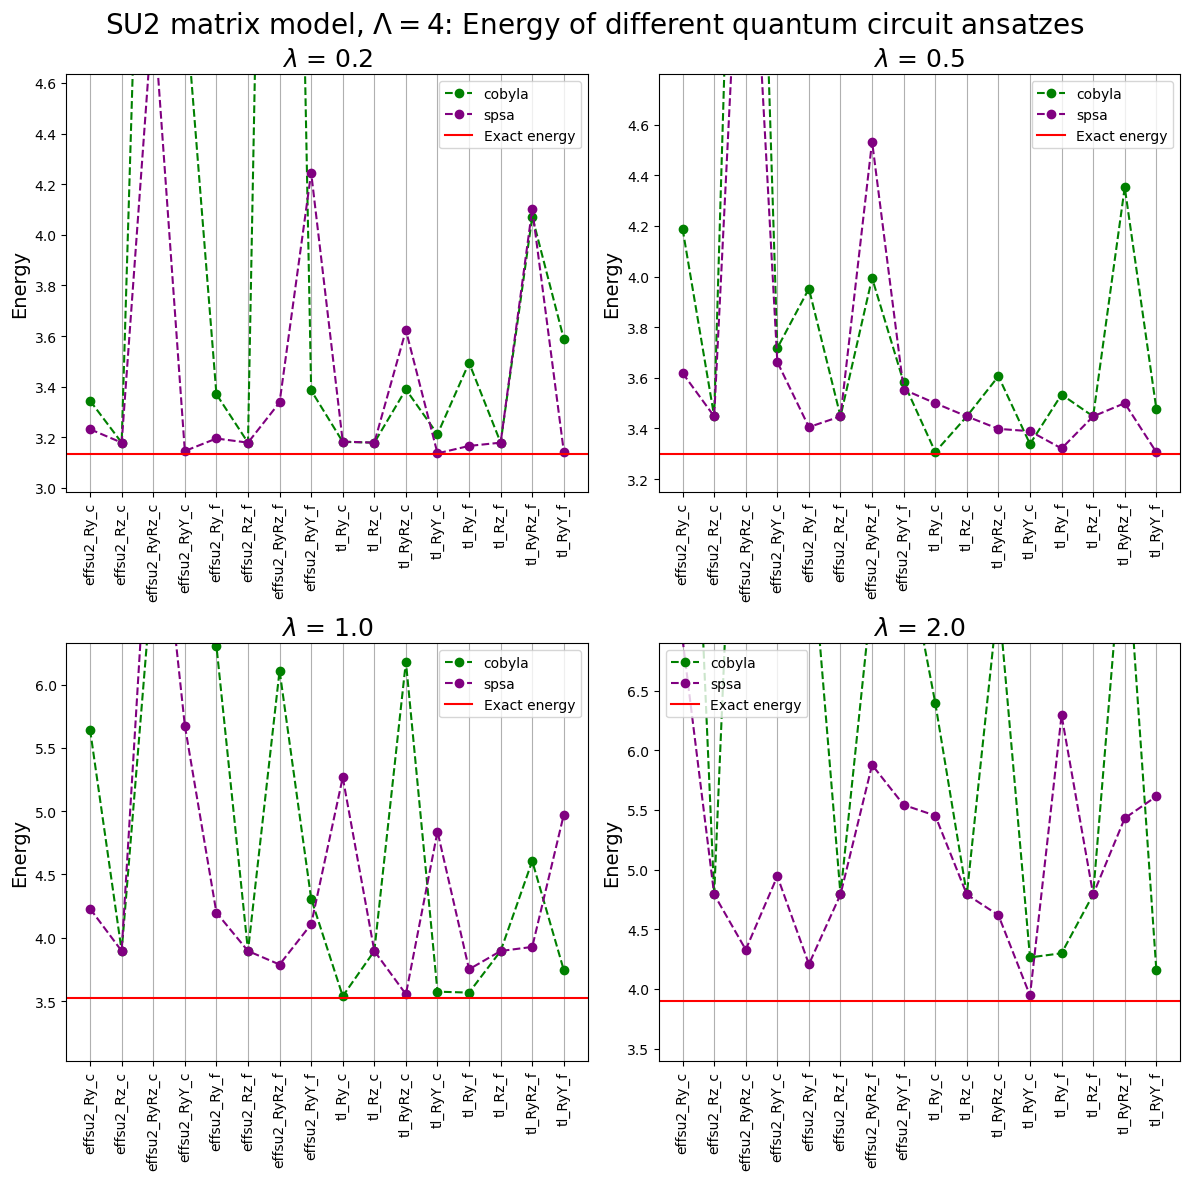

In [71]:
fig, ax = plt.subplots(2,2, figsize = (12,12), tight_layout= True)

plot_values(ax[0,0], df_l02, E_02, 0.2)
ax[0,0].set_ylim([E_02-0.15, E_02+1.5])

plot_values(ax[0,1], df_l05, E_05, 0.5)
ax[0,1].set_ylim([E_05-0.15, E_05+1.5])

plot_values(ax[1,0], df_l10, E_10, 1.0)
ax[1,0].set_ylim([E_10-0.5, E_10+2.8])

plot_values(ax[1,1], df_l20, E_20, 2.0, lloc = 'upper left')
ax[1,1].set_ylim([E_20-0.5, E_20+3.0])

plt.suptitle('SU2 matrix model, $\Lambda=4$: Energy of different quantum circuit ansatzes', fontsize = 20)
plt.savefig('L=4_all_ansatze_es_tl_1f.png')